# VM.AI Regressors — Difficulty & Importance Prediction
## Why Separate Regressors?
### The Problem: T5 Struggles with Numeric Fields
Throughout testing, we kept running into the same issue with T5 predicting `difficulty` and `importance`:
- **Semantic mismatch** — words like `"extreme"` would output `0.5`, while `"not difficult"` would output `0.85`
- **Binary-like outputs** — the model consistently mapped `"easy"` to `~0.15` and `"hard"` to `~0.85` with nothing in between
- **No per-task context** — `"hard homework"` and `"hard gym session"` got the same difficulty score even though they're totally different
- **Importance/difficulty confusion** — couldn't tell that `"hard homework"` might be less physically difficult but more important than `"hard gym session"`
We tried fixing this across multiple parser versions — changed architectures, restructured data, iterated on prompts. Same problem every time. The issue is fundamental: **T5 is a text-to-text model, not a regressor**. It generates tokens, not numbers. When trained to predict floats like `0.72`, it just learns surface-level token patterns instead of actual numeric relationships.
More training data would help a bit, but it doesn't fix the architectural mismatch.
### The Solution
We split the job: **dedicated XGBoost regressors** on top of **SentenceTransformer embeddings**:
- **SentenceTransformer** (`all-MiniLM-L6-v2`) converts text into 384-dim semantic embeddings that actually understand context and nuance
- **Two independent XGBoostRegressor models** predict `difficulty` and `importance` as real continuous floats in `[0, 1]`
- **Modular design** — regressors can be updated independently of the T5 parser
## Training Requirements
This notebook is nearly self-contained. It needs:
- **`src/parser/yaml_parser.py`** — parses YAML datasets into usable format
- **`src/parser/vars.py`** — shared constants (imported by `yaml_parser.py`)
- **`data/` folder** — training datasets (`VMAI_REAL_Data.yaml`, `VMAI_REGR_Data.yaml`, etc.)
- **Optional custom datasets** — extra labeled examples for edge cases or underrepresented task types
## Data Source
Training data comes from `data/VMAI_REAL_Data.yaml` + `data/VMAI_REGR_Data.yaml` — hand-labeled real user prompts with explicit `difficulty` and `importance` values. Merged into a single CSV for training.
## Train/Test Split
80/20 split with `random_state=42`. Models are evaluated on unseen test data for honest MAE and R².
## Integration
Trained models are saved as `.pkl` files and bundled with the T5 parser on HuggingFace (`vaneaa/vmai-parser`). At runtime, `TaskPlannerPredictor` loads both regressors and applies them during `predict_add()` and `predict_modify()`.

## EDA & Preprocessing
Load merged CSV, inspect distributions, check for missing values and class balance.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
from yaml_parser import VMAI_RealDataParser
from sentence_transformers import SentenceTransformer
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV
import random

ModuleNotFoundError: No module named 'yaml_parser'

Shape: (502, 3)

Missing values:
 text          0
difficulty    0
importance    0
dtype: int64

Dtypes:
 text           object
difficulty    float64
importance    float64
dtype: object

Difficulty stats:
count    502.000000
mean       0.421793
std        0.251843
min        0.050000
25%        0.200000
50%        0.400000
75%        0.550000
max        1.000000
Name: difficulty, dtype: float64

Importance stats:
count    502.000000
mean       0.592470
std        0.226484
min        0.100000
25%        0.450000
50%        0.600000
75%        0.750000
max        1.000000
Name: importance, dtype: float64


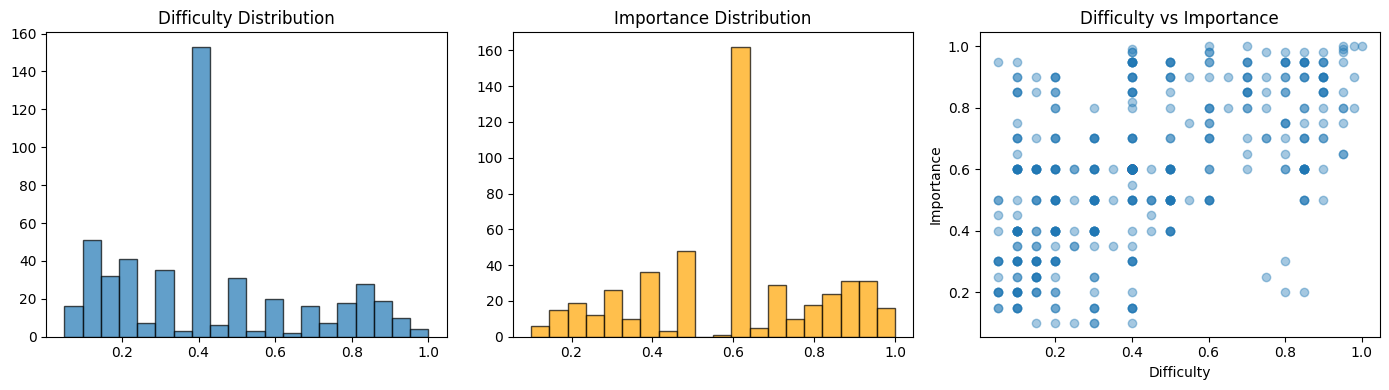

In [13]:
df = pd.read_csv("data/VMAI_REGR_Data.csv")

print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDtypes:\n", df.dtypes)
print("\nDifficulty stats:")
print(df['difficulty'].describe())
print("\nImportance stats:")
print(df['importance'].describe())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(df['difficulty'], bins=20, edgecolor='black', alpha=0.7)
axes[0].set_title('Difficulty Distribution')
axes[1].hist(df['importance'], bins=20, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Importance Distribution')
axes[2].scatter(df['difficulty'], df['importance'], alpha=0.4)
axes[2].set_xlabel('Difficulty')
axes[2].set_ylabel('Importance')
axes[2].set_title('Difficulty vs Importance')
plt.tight_layout()
plt.show()

In [14]:
train = pd.read_csv("data/VMAI_REGR_Data.csv")

X = train["text"].values
y_diff = train["difficulty"].values
y_imp = train["importance"].values

X_train, X_test, y_diff_train, y_diff_test, y_imp_train, y_imp_test = train_test_split(
    X, y_diff, y_imp, test_size=0.2, random_state=42
)

print(f"Train: {len(X_train)} samples")
print(f"Test:  {len(X_test)} samples")

Train: 401 samples
Test:  101 samples


In [15]:
encoder = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [16]:
emb_train = encoder.encode(X_train, show_progress_bar=False)
emb_test = encoder.encode(X_test, show_progress_bar=False)
print(f"Train embeddings: {emb_train.shape}")
print(f"Test embeddings:  {emb_test.shape}")

Train embeddings: (401, 384)
Test embeddings:  (101, 384)


In [23]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.5],
}

base = XGBRegressor(random_state=42, eval_metric='mae')

search_diff = RandomizedSearchCV(
    base, param_dist, n_iter=50,
    cv=5, scoring='neg_mean_absolute_error',
    random_state=42, verbose=1, n_jobs=-1
)

search_diff.fit(emb_train, y_diff_train)
print("Best diff params:", search_diff.best_params_)
print("Best CV MAE:", -search_diff.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best diff params: {'subsample': 0.6, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.6}
Best CV MAE: 0.14990011963070726


In [1]:
# These are the best params saved after finetuning
best_params = {'subsample': 0.6, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.6}

In [4]:
diff_model = XGBRegressor(
    subsample=0.6, n_estimators=500, min_child_weight=7,
    max_depth=6, learning_rate=0.01, gamma=0, colsample_bytree=0.6,
    random_state=42
)
diff_model.fit(
    emb_train, y_diff_train,
    eval_set=[(emb_test, y_diff_test)],
    verbose=True
)
joblib.dump(diff_model, 'difficulty_regressor.pkl')
print("Difficulty regressor trained and saved.")

NameError: name 'XGBRegressor' is not defined

In [2]:
imp_model = XGBRegressor(
    subsample=0.6, n_estimators=500, min_child_weight=7,
    max_depth=6, learning_rate=0.01, gamma=0, colsample_bytree=0.6,
    random_state=42
)
imp_model.fit(
    emb_train, y_imp_train,
    eval_set=[(emb_test, y_imp_test)],
    verbose=True
)
joblib.dump(imp_model, 'importance_regressor.pkl')
print("Importance regressor trained and saved.")

NameError: name 'XGBRegressor' is not defined

In [19]:
pred_diff = np.clip(diff_model.predict(emb_test), 0, 1)
pred_imp = np.clip(imp_model.predict(emb_test), 0, 1)

print(f"Difficulty MAE: {mean_absolute_error(y_diff_test, pred_diff):.4f} | R²: {r2_score(y_diff_test, pred_diff):.4f}")
print(f"Importance MAE: {mean_absolute_error(y_imp_test, pred_imp):.4f} | R²: {r2_score(y_imp_test, pred_imp):.4f}")
print()
print("First 5 test predictions:")
for i in range(min(5, len(X_test))):
    print(f"  {X_test[i][:60]:<60} diff={pred_diff[i]:.3f} (true={y_diff_test[i]:.3f})  imp={pred_imp[i]:.3f} (true={y_imp_test[i]:.3f})")

Difficulty MAE: 0.1464 | R²: 0.3417
Importance MAE: 0.1431 | R²: 0.2982

First 5 test predictions:
  30 minutes and its very important today                      diff=0.396 (true=0.400)  imp=0.433 (true=0.820)
  decent amount of work                                        diff=0.628 (true=0.500)  imp=0.478 (true=0.500)
  practice the piano                                           diff=0.415 (true=0.450)  imp=0.463 (true=0.400)
  perform a complex dental surgery on a nervous patient        diff=0.492 (true=0.900)  imp=0.794 (true=0.900)
  was thinking of doing a quick grocery run later              diff=0.329 (true=0.150)  imp=0.444 (true=0.500)


In [20]:
sentences = ["hard workout", "easy stretch", "urgent call", "critical fix"]
emb = encoder.encode(sentences)
for s, d, i in zip(sentences, np.clip(diff_model.predict(emb), 0, 1), np.clip(imp_model.predict(emb), 0, 1)):
    print(f"{s:<25} diff={d:.3f} imp={i:.3f}")

hard workout              diff=0.846 imp=0.475
easy stretch              diff=0.151 imp=0.297
urgent call               diff=0.456 imp=0.628
critical fix              diff=0.609 imp=0.863


In [21]:
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import files
    files.download('difficulty_regressor.pkl')
    files.download('importance_regressor.pkl')
    print("Models downloaded.")
else:
    print("Running locally — models saved to disk:")
    print("  difficulty_regressor.pkl")
    print("  importance_regressor.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Models downloaded.
